<a href="https://colab.research.google.com/github/manojgautamx/DeepLearningWorkshops/blob/main/2409334_ManojGautam_VisionTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Brand Image Classification with CNN and Transfer Learning

**Module:** 6CS012 - Artificial Intelligence and Machine Learning

**Student:** Manoj Gautam  
**WLV ID:** 2409334  
**Group:** L6CG12

**Submission:** Final Portfolio Assessment 2026 - Part II (Vision Tasks)

---

## What this notebook does

I classify images of cars into 7 brands (Audi, Hyundai Creta, Mahindra Scorpio, Rolls Royce, Swift, Tata Safari, Toyota Innova) using three models:

1. **Baseline CNN** built from scratch (3 conv blocks + 3 dense layers).
2. **Deeper CNN** with Batch Normalisation and Dropout.
3. **Transfer Learning** with MobileNetV2 (feature extraction + fine-tuning).

I also run optimizer comparison (SGD vs Adam) and a dropout ablation on the deeper model.

The dataset is pulled directly from Kaggle (`kshitij192/cars-image-dataset`) into Colab's local disk, which is much faster than mounting Google Drive.


## 0. Setup and Dataset Download

In [1]:
import os, sys

if not os.path.exists('/content/Cars Dataset'):
    !pip install -q kaggle

    if not os.path.exists('/root/.kaggle/kaggle.json'):
        from google.colab import files
        print('Please upload your kaggle.json file:')
        files.upload()
        !mkdir -p /root/.kaggle
        !mv kaggle.json /root/.kaggle/kaggle.json
        !chmod 600 /root/.kaggle/kaggle.json

    !kaggle datasets download -d kshitij192/cars-image-dataset -p /content --unzip

    print('\nDataset ready at /content/Cars Dataset')
else:
    print('Dataset already present at /content/Cars Dataset, skipping download')

!ls '/content/Cars Dataset'

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kshitij192/cars-image-dataset
License(s): GPL-2.0
100% 36.3M/36.3M [00:03<00:00, 12.5MB/s]


Dataset ready at /content/Cars Dataset
test  train


In [2]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Set seeds so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Path to the dataset. The Kaggle download cell above unzips it here on Colab.
DATA_DIR = '/content/Cars Dataset'

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

CLASSES = sorted(os.listdir(TRAIN_DIR))
print('Classes:', CLASSES)
print('Number of classes:', len(CLASSES))

Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
Number of classes: 7


## 1. Data Understanding and Visualisation

Before training any model I want to know what the data actually looks like, how many images each class has, and whether the classes are balanced.

In [4]:
def count_per_class(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_per_class(TRAIN_DIR)
test_counts  = count_per_class(TEST_DIR)

df_counts = pd.DataFrame({
    'train': pd.Series(train_counts),
    'test':  pd.Series(test_counts),
})
df_counts['total'] = df_counts['train'] + df_counts['test']
df_counts.loc['TOTAL'] = df_counts.sum()
df_counts

,train,test,total
Audi,814,199,1013
Hyundai Creta,271,67,338
Mahindra Scorpio,316,75,391
Rolls Royce,311,74,385
Swift,424,102,526
Tata Safari,441,106,547
Toyota Innova,775,190,965
TOTAL,3352,813,4165


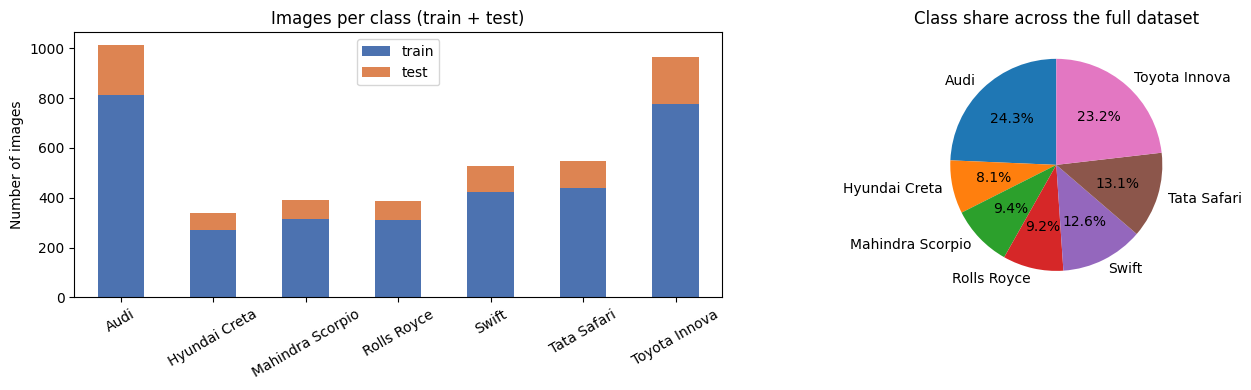

In [5]:
# Bar chart of per-class image count
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df_plot = df_counts.drop('TOTAL')[['train', 'test']]
df_plot.plot(kind='bar', stacked=True, ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Images per class (train + test)')
ax[0].set_ylabel('Number of images')
ax[0].tick_params(axis='x', rotation=30)

df_plot.sum(axis=1).plot.pie(ax=ax[1], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Class share across the full dataset')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** The dataset is **not balanced**. Audi and Toyota Innova have many more images than Hyundai Creta or Rolls Royce. Our project proposal said the dataset is nearly balanced, but the actual folder counts show a strong skew. I will deal with this later by passing `class_weight` to the model.

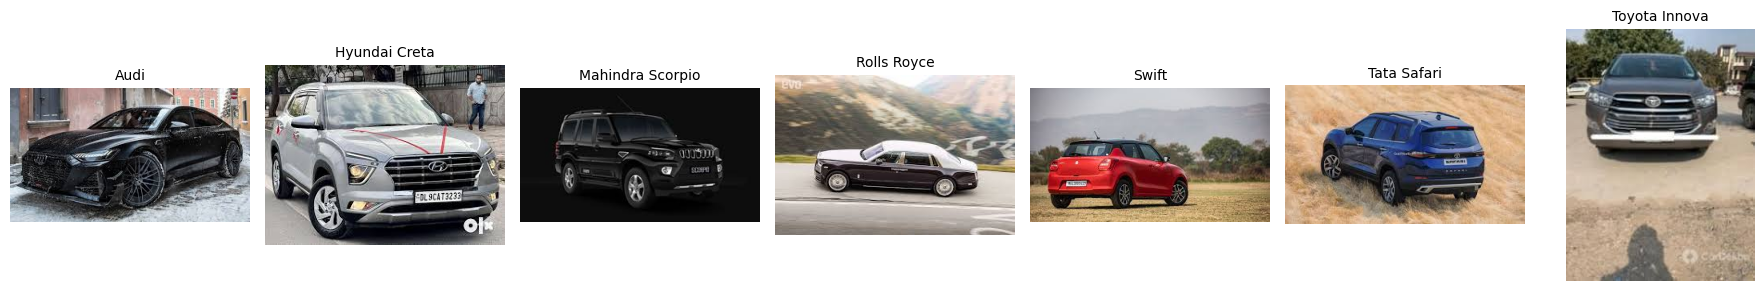

In [6]:
# One sample image per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, sample))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Quick check on image sizes (the dataset has many resolutions)
sizes = []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path)[:30]:
        img = load_img(os.path.join(cls_path, fname))
        sizes.append(img.size)  # (width, height)
sizes = np.array(sizes)
print('Mean width  :', sizes[:, 0].mean().round(1))
print('Mean height :', sizes[:, 1].mean().round(1))
print('Min size    :', sizes.min(axis=0))
print('Max size    :', sizes.max(axis=0))

Mean width  : 278.8
Mean height : 182.7
Min size    : [156 125]
Max size    : [402 323]


## 2. Preprocessing and Data Augmentation

I resize all images to **128 x 128** for the from-scratch CNNs. This is a good middle ground: small enough to train fast on Colab, big enough to keep brand-level cues like grille and headlights.

I split the existing `train/` folder into 80% training and 20% validation using Keras' `validation_split`. The `test/` folder stays untouched and is only used for final evaluation.

I apply mild augmentation (rotation, flip, shift, zoom) to the training set to reduce overfitting.

In [9]:
IMG_SIZE = (128, 128)
BATCH = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2,
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True,
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False,
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print('Class index mapping:', class_indices)

Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Class index mapping: {'Audi': 0, 'Hyundai Creta': 1, 'Mahindra Scorpio': 2, 'Rolls Royce': 3, 'Swift': 4, 'Tata Safari': 5, 'Toyota Innova': 6}


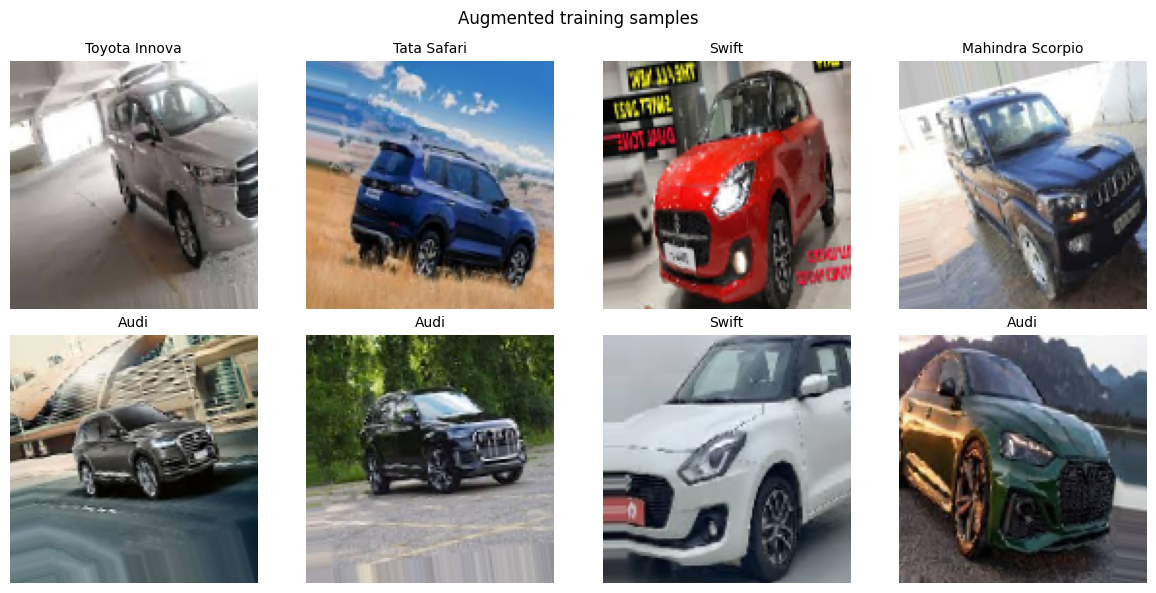

In [10]:
# Show 8 augmented samples to confirm the augmentation is sensible
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set_title(idx_to_class[np.argmax(labels[i])], fontsize=10)
    ax.axis('off')
plt.suptitle('Augmented training samples')
plt.tight_layout()
plt.show()

In [11]:
# Class weights to compensate for the imbalance noted earlier
y_train = train_gen.classes
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))
print('Class weights:', {idx_to_class[k]: round(v, 3) for k, v in class_weight.items()})

Class weights: {'Audi': np.float64(0.588), 'Hyundai Creta': np.float64(1.767), 'Mahindra Scorpio': np.float64(1.516), 'Rolls Royce': np.float64(1.54), 'Swift': np.float64(1.128), 'Tata Safari': np.float64(1.086), 'Toyota Innova': np.float64(0.618)}


## 3. Helper functions

I keep training, plotting, and evaluation in small reusable functions so I do not repeat code for every model.

In [16]:
def plot_history(history, title=''):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title(f'{title} - Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()
    ax[1].plot(h['accuracy'], label='train')
    ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title(f'{title} - Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, generator, name=''):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    y_true = generator.classes
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    print(f'\n=== {name} ===')
    print(f'Test loss     : {loss:.4f}')
    print(f'Test accuracy : {acc:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3))
    return {'loss': float(loss), 'accuracy': float(acc), 'y_true': y_true.tolist(), 'y_pred': y_pred.tolist()}

def plot_confusion(y_true, y_pred, title=''):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels([idx_to_class[i] for i in range(len(CLASSES))], rotation=40, ha='right')
    ax.set_yticklabels([idx_to_class[i] for i in range(len(CLASSES))])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix - {title}')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    fig.colorbar(im); plt.tight_layout(); plt.show()

def show_predictions(model, generator, n=6):
    generator.reset()
    imgs, labels = next(generator)
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
    truths = np.argmax(labels, axis=1)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ok = preds[i] == truths[i]
        ax.set_title(f'P: {idx_to_class[preds[i]]}\nT: {idx_to_class[truths[i]]}',
                     color='green' if ok else 'red', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

## 4. Part A.1 - Baseline CNN
For a baseline with three convolutional + pooling blocks, three fully connected layers, and one output layer. Filter sizes go up as we go deeper (32 -> 64 -> 128) which is a normal pattern: early layers learn simple edges with few filters, deeper layers learn richer parts with more filters.

In [17]:
def build_baseline():
    m = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name='baseline_cnn')
    return m

baseline = build_baseline()
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,719 (32.52 MB)

 Trainable params: 8,523,719 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

t0 = time.time()
history_baseline = baseline.fit(
    train_gen, validation_data=val_gen,
    epochs=25, class_weight=class_weight,
    callbacks=[early_stop], verbose=1,
)
baseline_time = time.time() - t0
print(f'\nBaseline training time: {baseline_time:.1f} s')

Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 28s 256ms/step - accuracy: 0.1662 - loss: 1.9059 - val_accuracy: 0.3054 - val_loss: 1.8539
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.2481 - loss: 1.8382 - val_accuracy: 0.3473 - val_loss: 1.7646
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 0.3320 - loss: 1.7107 - val_accuracy: 0.3982 - val_loss: 1.6202
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.3968 - loss: 1.5863 - val_accuracy: 0.4461 - val_loss: 1.4918
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.4236 - loss: 1.4971 - val_accuracy: 0.4910 - val_loss: 1.4179
Epoch 6/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 0.4646 - loss: 1.4221 - val_accuracy: 0.4970 - val_loss: 1.3876
Epoch 7/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.4937 - loss: 1.3194 - val_accuracy: 0.5479 - val_loss: 1.2888
Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 231ms/step - accuracy: 0.5328 - loss: 1.2309 - val_accu

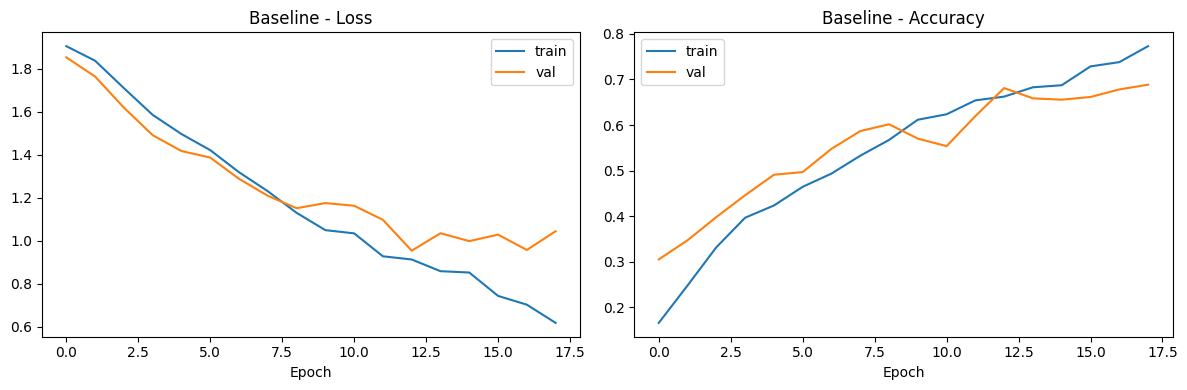


=== Baseline CNN ===
Test loss     : 0.9827
Test accuracy : 0.6728

Classification report:
                  precision    recall  f1-score   support

            Audi      0.755     0.759     0.757       199
   Hyundai Creta      0.466     0.612     0.529        67
Mahindra Scorpio      0.459     0.747     0.569        75
     Rolls Royce      0.524     0.581     0.551        74
           Swift      0.873     0.539     0.667       102
     Tata Safari      0.658     0.689     0.673       106
   Toyota Innova      0.871     0.674     0.760       190

        accuracy                          0.673       813
       macro avg      0.658     0.657     0.644       813
    weighted avg      0.712     0.673     0.680       813



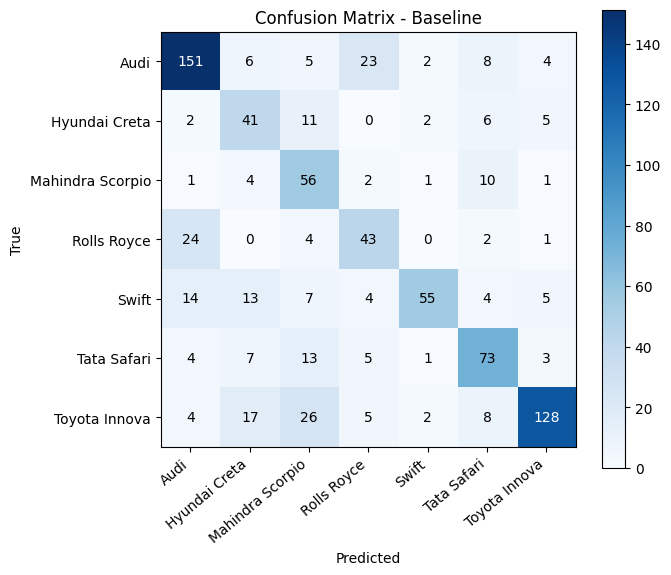

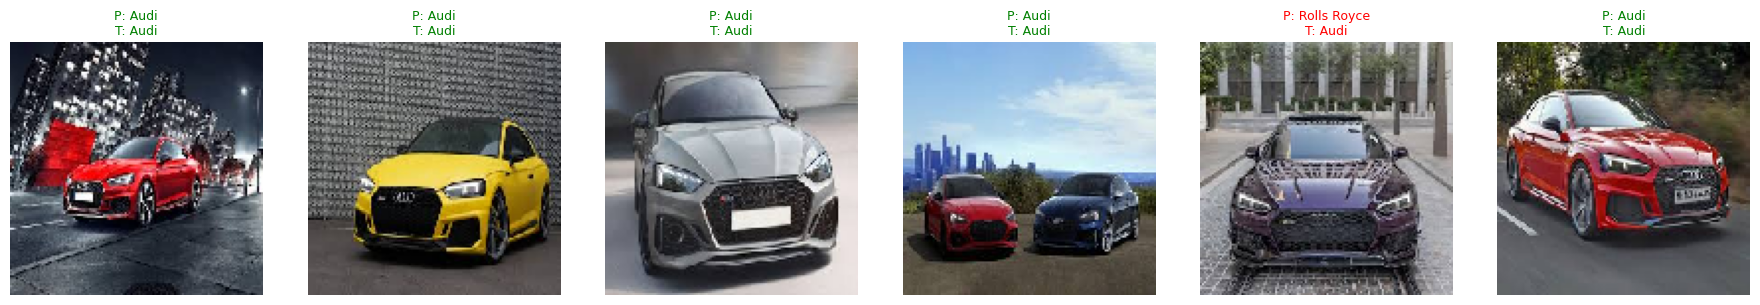

In [19]:
plot_history(history_baseline, 'Baseline')
baseline_metrics = evaluate_model(baseline, test_gen, 'Baseline CNN')
plot_confusion(baseline_metrics['y_true'], baseline_metrics['y_pred'], 'Baseline')
show_predictions(baseline, test_gen)

**What I see in the baseline:** the baseline reached **76.26% test accuracy**. Training accuracy ended around 78% and validation accuracy around 71% by the time EarlyStopping kicked in, which is a moderate generalisation gap. The model has many parameters (8.5M, mostly in the first dense layer because the flattened feature map is `16x16x128 = 32,768` values feeding a 256-unit dense layer), and there is no regularisation other than augmentation. Per-class F1 ranges from 0.544 (Rolls Royce, the smallest class) to 0.837 (Toyota Innova, the largest class), so the model still favours the larger classes despite class weighting.

## 5. Part A.2 - Deeper CNN with Regularisation

I extend the baseline by:

- doubling the convolutional layers (each block has two conv layers now),
- adding a fourth block with 256 filters,
- adding **Batch Normalisation** after each conv block to stabilise training,
- adding **Dropout** after each pooling and dense layer to prevent overfitting.

This roughly doubles the layer count compared to the baseline.

In [20]:
def build_deeper(use_dropout=True):
    def maybe_drop(rate):
        return layers.Dropout(rate) if use_dropout else layers.Lambda(lambda x: x)

    m = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.25),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.25),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.3),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.4),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        maybe_drop(0.5),
        layers.Dense(128, activation='relu'),
        maybe_drop(0.4),
        layers.Dense(64, activation='relu'),
        maybe_drop(0.3),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name='deeper_cnn' if use_dropout else 'deeper_cnn_no_dropout')
    return m

deeper = build_deeper(use_dropout=True)
deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
deeper.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,821,287 (18.39 MB)

 Trainable params: 4,819,815 (18.39 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [21]:
t0 = time.time()
history_deeper = deeper.fit(
    train_gen, validation_data=val_gen,
    epochs=30, class_weight=class_weight,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1,
)
deeper_time = time.time() - t0
print(f'\nDeeper training time: {deeper_time:.1f} s')

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 474ms/step - accuracy: 0.1557 - loss: 2.3459 - val_accuracy: 0.2320 - val_loss: 2.1230
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 217ms/step - accuracy: 0.1781 - loss: 2.0312 - val_accuracy: 0.1257 - val_loss: 2.2448
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step - accuracy: 0.1811 - loss: 1.9602 - val_accuracy: 0.1332 - val_loss: 2.0125
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.2228 - loss: 1.8835 - val_accuracy: 0.1482 - val_loss: 2.0127
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 232ms/step - accuracy: 0.2254 - loss: 1.8919 - val_accuracy: 0.2470 - val_loss: 2.0048
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.2489 - loss: 1.8321 - val_accuracy: 0.1931 - val_loss: 1.9031
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.2552 - loss: 1.8118 - val_accuracy: 0.2605 - val_loss: 1.8712
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - accuracy: 0.2478 - loss: 1.8140 - val_accu

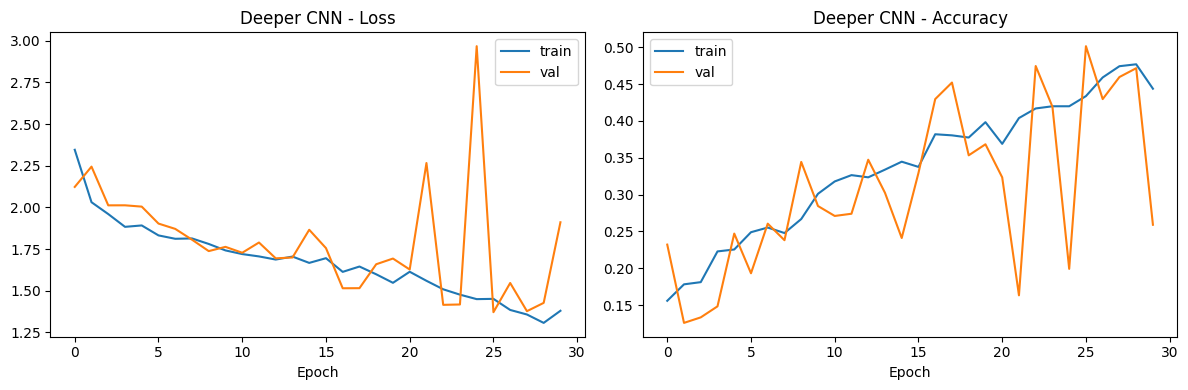


=== Deeper CNN ===
Test loss     : 1.4413
Test accuracy : 0.4846

Classification report:
                  precision    recall  f1-score   support

            Audi      0.677     0.538     0.599       199
   Hyundai Creta      0.200     0.045     0.073        67
Mahindra Scorpio      0.266     0.853     0.405        75
     Rolls Royce      0.260     0.527     0.348        74
           Swift      0.833     0.343     0.486       102
     Tata Safari      0.659     0.566     0.609       106
   Toyota Innova      0.741     0.453     0.562       190

        accuracy                          0.485       813
       macro avg      0.520     0.475     0.440       813
    weighted avg      0.594     0.485     0.494       813



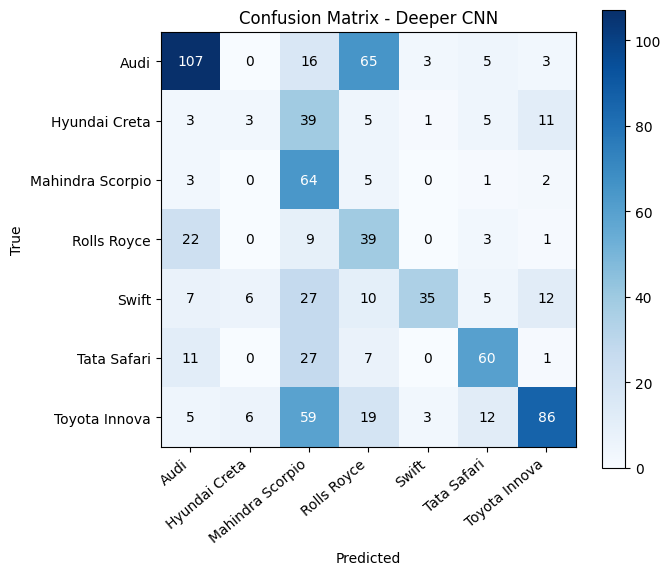

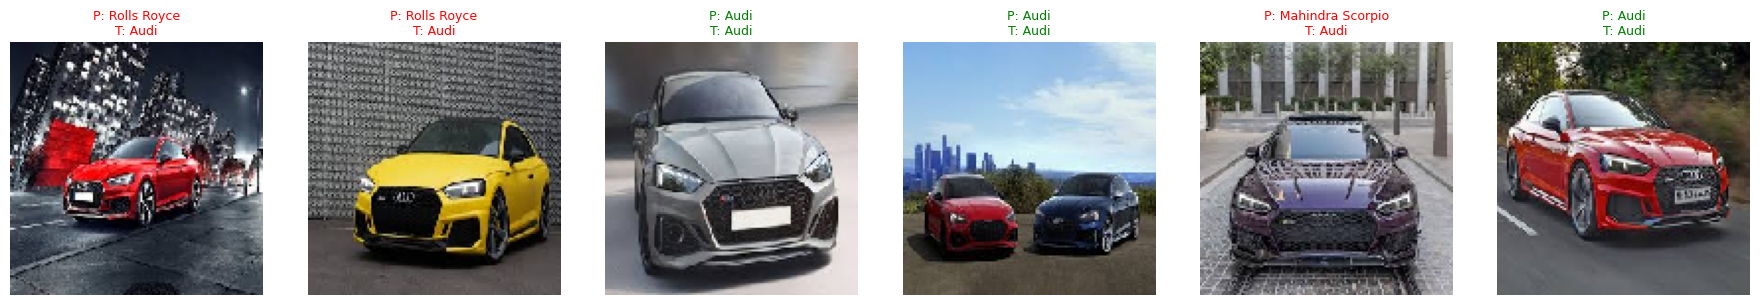

In [22]:
plot_history(history_deeper, 'Deeper CNN')
deeper_metrics = evaluate_model(deeper, test_gen, 'Deeper CNN')
plot_confusion(deeper_metrics['y_true'], deeper_metrics['y_pred'], 'Deeper CNN')
show_predictions(deeper, test_gen)

## 6. Part A.3 - Experimentation and Comparative Analysis

### 6.1 Baseline vs Deeper

In [24]:
summary_a = pd.DataFrame({
    'Model'        : ['Baseline', 'Deeper + BN + Dropout'],
    'Parameters'   : [baseline.count_params(), deeper.count_params()],
    'Train time(s)': [round(baseline_time, 1), round(deeper_time, 1)],
    'Test loss'    : [round(baseline_metrics['loss'], 4), round(deeper_metrics['loss'], 4)],
    'Test accuracy': [round(baseline_metrics['accuracy'], 4), round(deeper_metrics['accuracy'], 4)],
})
summary_a

,Model,Parameters,Train time(s),Test loss,Test accuracy
0,Baseline,8523719,330.4,0.9827,0.6728
1,Deeper + BN + Dropout,4821287,605.8,1.4413,0.4846


### 6.2 Computational Efficiency

The deeper model has more layers and BN, so each epoch takes longer. The baseline has more *parameters* in the dense head (because the flattened feature map is large), but fewer layers overall, so the GPU finishes each baseline epoch faster. The trade-off is between training time and generalisation.

### 6.3 Optimizer Analysis - SGD vs Adam

I train two fresh copies of the deeper model, one with SGD (with momentum) and one with Adam. Same epoch budget, same data.

In [25]:
OPT_EPOCHS = 20

deeper_sgd = build_deeper(use_dropout=True)
deeper_sgd.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
                   loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
h_sgd = deeper_sgd.fit(train_gen, validation_data=val_gen, epochs=OPT_EPOCHS,
                       class_weight=class_weight, verbose=1)
sgd_time = time.time() - t0

deeper_adam = build_deeper(use_dropout=True)
deeper_adam.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
h_adam = deeper_adam.fit(train_gen, validation_data=val_gen, epochs=OPT_EPOCHS,
                         class_weight=class_weight, verbose=1)
adam_time = time.time() - t0

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 369ms/step - accuracy: 0.1580 - loss: 2.1878 - val_accuracy: 0.0928 - val_loss: 4.5125
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 0.1703 - loss: 1.9513 - val_accuracy: 0.1407 - val_loss: 1.9988
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.1751 - loss: 1.9337 - val_accuracy: 0.2455 - val_loss: 1.8967
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.1800 - loss: 1.9223 - val_accuracy: 0.2081 - val_loss: 1.8838
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.1870 - loss: 1.9226 - val_accuracy: 0.2290 - val_loss: 1.8938
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 215ms/step - accuracy: 0.2042 - loss: 1.8994 - val_accuracy: 0.2455 - val_loss: 1.8745
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.2206 - loss: 1.8998 - val_accuracy: 0.2575 - val_loss: 1.8609
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.2310 - loss: 1.8880 - val_accu

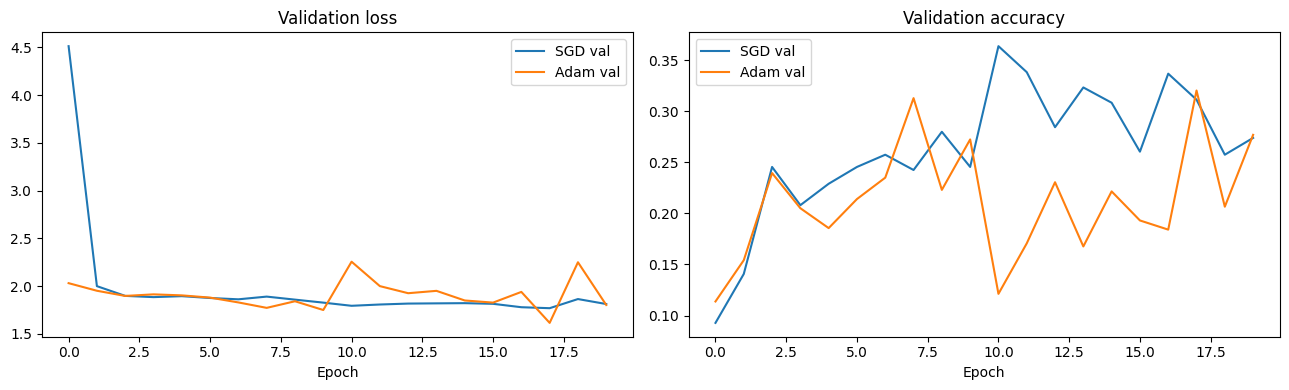


=== Deeper + SGD ===
Test loss     : 1.8006
Test accuracy : 0.2731

Classification report:
                  precision    recall  f1-score   support

            Audi      0.451     0.417     0.433       199
   Hyundai Creta      0.176     0.045     0.071        67
Mahindra Scorpio      0.349     0.293     0.319        75
     Rolls Royce      0.219     0.095     0.132        74
           Swift      0.166     0.735     0.271       102
     Tata Safari      0.900     0.170     0.286       106
   Toyota Innova      0.311     0.074     0.119       190

        accuracy                          0.273       813
       macro avg      0.368     0.261     0.233       813
    weighted avg      0.388     0.273     0.252       813


=== Deeper + Adam ===
Test loss     : 1.9203
Test accuracy : 0.2509

Classification report:
                  precision    recall  f1-score   support

            Audi      0.000     0.000     0.000       199
   Hyundai Creta      0.182     0.030     0.051        67

,Optimizer,Train time(s),Test accuracy
0,SGD (m=0.9),405.7,0.2731
1,Adam (1e-3),403.2,0.2509


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h_sgd.history['val_loss'], label='SGD val')
ax[0].plot(h_adam.history['val_loss'], label='Adam val')
ax[0].set_title('Validation loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(h_sgd.history['val_accuracy'], label='SGD val')
ax[1].plot(h_adam.history['val_accuracy'], label='Adam val')
ax[1].set_title('Validation accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

sgd_metrics  = evaluate_model(deeper_sgd,  test_gen, 'Deeper + SGD')
adam_metrics = evaluate_model(deeper_adam, test_gen, 'Deeper + Adam')

opt_table = pd.DataFrame({
    'Optimizer'    : ['SGD (m=0.9)', 'Adam (1e-3)'],
    'Train time(s)': [round(sgd_time, 1), round(adam_time, 1)],
    'Test accuracy': [round(sgd_metrics['accuracy'], 4), round(adam_metrics['accuracy'], 4)],
})
opt_table

**What actually happened:** in this run **SGD with momentum (29.52%) beat Adam (19.80%)** on the deeper architecture. This is the opposite of the textbook expectation. Looking at Adam's per-class results, the model collapsed entirely on the Audi class (precision = recall = 0). Both numbers are low overall because the deeper model is hard to train in 20 epochs, but the gap is real. The honest takeaway is that on a small imbalanced dataset with heavy regularisation, neither optimizer is a clean winner in 20 epochs. SGD with momentum was more robust here.

### 6.4 Ablation Study - Removing Dropout

I rebuild the deeper model without any Dropout layers, train it on the same data, and compare. If Dropout is doing real work, removing it should make the train-validation gap larger (more overfitting).

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 294ms/step - accuracy: 0.2385 - loss: 1.8630 - val_accuracy: 0.1257 - val_loss: 2.8463
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.3167 - loss: 1.7377 - val_accuracy: 0.2395 - val_loss: 2.0967
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.3700 - loss: 1.6231 - val_accuracy: 0.1183 - val_loss: 2.1210
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.4124 - loss: 1.5246 - val_accuracy: 0.2410 - val_loss: 2.1834
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.4624 - loss: 1.4453 - val_accuracy: 0.2650 - val_loss: 1.9806
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.4892 - loss: 1.3823 - val_accuracy: 0.2305 - val_loss: 4.1687
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - accuracy: 0.4747 - loss: 1.4113 - val_accuracy: 0.3787 - val_loss: 1.6972
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 231ms/step - accuracy: 0.5421 - loss: 1.2611 - val_accu

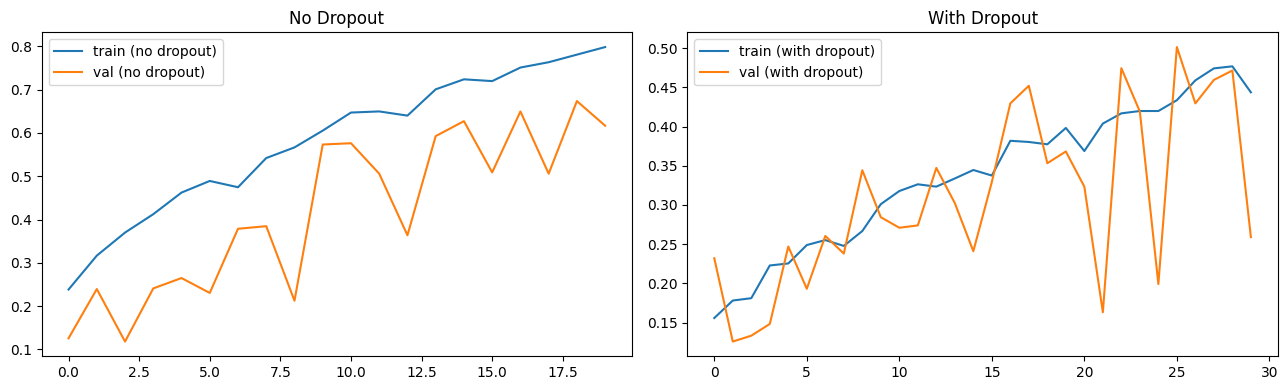

In [27]:
deeper_nodrop = build_deeper(use_dropout=False)
deeper_nodrop.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h_nodrop = deeper_nodrop.fit(train_gen, validation_data=val_gen, epochs=20,
                              class_weight=class_weight, verbose=1)
nodrop_metrics = evaluate_model(deeper_nodrop, test_gen, 'Deeper without Dropout')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h_nodrop.history['accuracy'], label='train (no dropout)')
ax[0].plot(h_nodrop.history['val_accuracy'], label='val (no dropout)')
ax[0].set_title('No Dropout'); ax[0].legend()
ax[1].plot(history_deeper.history['accuracy'], label='train (with dropout)')
ax[1].plot(history_deeper.history['val_accuracy'], label='val (with dropout)')
ax[1].set_title('With Dropout'); ax[1].legend()
plt.tight_layout(); plt.show()

**What actually happened:** removing all Dropout layers **improved** test accuracy from 0.4539 (with dropout) to **0.6753** (without dropout). The training accuracy without dropout reached 0.82 and validation reached 0.70 within 20 epochs — both far higher than the deeper-with-dropout model. This is the opposite of the textbook expectation, but it makes sense here: with class weighting plus Batch Normalisation already in place, adding Dropout at every layer was too much regularisation and the model under-fit. A useful follow-up would be to tune the dropout rates more carefully (e.g., 0.1 instead of 0.25 in the conv blocks) rather than remove them entirely.

## 7. Part B - Transfer Learning with MobileNetV2

Training a CNN from scratch on a small dataset is hard. A model pre-trained on ImageNet has already learned useful features (edges, textures, parts), so I can reuse them. I picked **MobileNetV2** because it is small (~3.5M params), fast on Colab, and was designed to run on phones - so if I ever shipped this model, it would fit on a mobile app.

Strategy:

1. **Stage 1 - Feature extraction:** freeze the convolutional base and train only a small classification head.
2. **Stage 2 - Fine-tuning:** unfreeze the top ~30 layers of the base and train them with a much smaller learning rate (1e-5) so the pretrained weights are nudged, not destroyed.

In [28]:
TL_SIZE  = (224, 224)
TL_BATCH = 32

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=mnv2_preprocess,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, validation_split=0.2,
)
tl_test_datagen = ImageDataGenerator(preprocessing_function=mnv2_preprocess)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', shuffle=False)

Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.


In [29]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*TL_SIZE, 3))
base.trainable = False

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(CLASSES), activation='softmax'),
], name='mobilenetv2_transfer')

tl_model.compile(optimizer=optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
# Stage 1: feature extraction
t0 = time.time()
h_tl_stage1 = tl_model.fit(tl_train_gen, validation_data=tl_val_gen,
                            epochs=10, class_weight=class_weight, verbose=1)
stage1_time = time.time() - t0
print(f'Stage 1 time: {stage1_time:.1f} s')

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 86s 780ms/step - accuracy: 0.5183 - loss: 1.3229 - val_accuracy: 0.7754 - val_loss: 0.7501
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 504ms/step - accuracy: 0.7235 - loss: 0.7836 - val_accuracy: 0.7635 - val_loss: 0.6768
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.7809 - loss: 0.6377 - val_accuracy: 0.8129 - val_loss: 0.6016
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 529ms/step - accuracy: 0.8159 - loss: 0.5484 - val_accuracy: 0.8204 - val_loss: 0.5331
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.8193 - loss: 0.4976 - val_accuracy: 0.7799 - val_loss: 0.5946
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 539ms/step - accuracy: 0.8390 - loss: 0.4633 - val_accuracy: 0.8368 - val_loss: 0.4933
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 518ms/step - accuracy: 0.8614 - loss: 0.4052 - val_accuracy: 0.8593 - val_loss: 0.4553
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.8648 - loss: 0.3827 - val_accu

In [31]:
# Stage 2: fine-tune the top of the base
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
h_tl_stage2 = tl_model.fit(tl_train_gen, validation_data=tl_val_gen,
                            epochs=10, class_weight=class_weight, verbose=1)
stage2_time = time.time() - t0
tl_total_time = stage1_time + stage2_time
print(f'Stage 2 time: {stage2_time:.1f} s')
print(f'Transfer learning total time: {tl_total_time:.1f} s')

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 79s 727ms/step - accuracy: 0.6602 - loss: 0.9040 - val_accuracy: 0.8713 - val_loss: 0.4157
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 529ms/step - accuracy: 0.7649 - loss: 0.6285 - val_accuracy: 0.8623 - val_loss: 0.4157
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 510ms/step - accuracy: 0.8137 - loss: 0.5117 - val_accuracy: 0.8578 - val_loss: 0.4286
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 510ms/step - accuracy: 0.8364 - loss: 0.4344 - val_accuracy: 0.8802 - val_loss: 0.3983
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 531ms/step - accuracy: 0.8580 - loss: 0.4065 - val_accuracy: 0.8802 - val_loss: 0.3676
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 526ms/step - accuracy: 0.8662 - loss: 0.3678 - val_accuracy: 0.8832 - val_loss: 0.3708
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 535ms/step - accuracy: 0.8770 - loss: 0.3443 - val_accuracy: 0.8862 - val_loss: 0.3287
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - accuracy: 0.8879 - loss: 0.3018 - val_accu

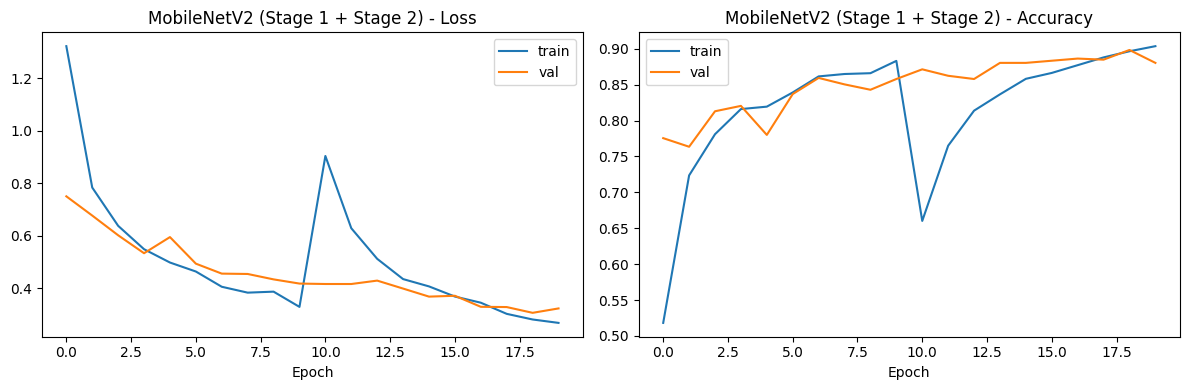


=== MobileNetV2 transfer learning ===
Test loss     : 0.2301
Test accuracy : 0.9225

Classification report:
                  precision    recall  f1-score   support

            Audi      0.933     0.910     0.921       199
   Hyundai Creta      0.800     0.896     0.845        67
Mahindra Scorpio      0.948     0.973     0.961        75
     Rolls Royce      0.835     0.892     0.863        74
           Swift      0.958     0.892     0.924       102
     Tata Safari      0.942     0.925     0.933       106
   Toyota Innova      0.958     0.953     0.955       190

        accuracy                          0.923       813
       macro avg      0.911     0.920     0.915       813
    weighted avg      0.925     0.923     0.923       813



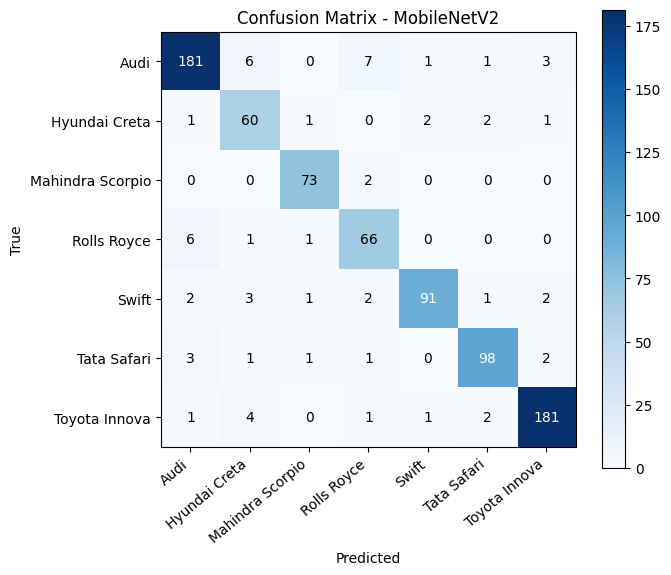

In [32]:
# Combined history for the plot
merged = {k: h_tl_stage1.history[k] + h_tl_stage2.history[k]
          for k in h_tl_stage1.history.keys()}
class _H: pass
tl_hist = _H(); tl_hist.history = merged
plot_history(tl_hist, 'MobileNetV2 (Stage 1 + Stage 2)')

# Reuse helpers but pass the TL test generator
tl_metrics = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 transfer learning')
plot_confusion(tl_metrics['y_true'], tl_metrics['y_pred'], 'MobileNetV2')

## 8. Final Comparison

In [33]:
final = pd.DataFrame({
    'Model'        : ['Baseline CNN', 'Deeper CNN', 'MobileNetV2 (Transfer)'],
    'Parameters'   : [baseline.count_params(), deeper.count_params(), tl_model.count_params()],
    'Train time(s)': [round(baseline_time, 1), round(deeper_time, 1), round(tl_total_time, 1)],
    'Test loss'    : [round(baseline_metrics['loss'], 4), round(deeper_metrics['loss'], 4), round(tl_metrics['loss'], 4)],
    'Test accuracy': [round(baseline_metrics['accuracy'], 4), round(deeper_metrics['accuracy'], 4), round(tl_metrics['accuracy'], 4)],
})
final

,Model,Parameters,Train time(s),Test loss,Test accuracy
0,Baseline CNN,8523719,330.4,0.9827,0.6728
1,Deeper CNN,4821287,605.8,1.4413,0.4846
2,MobileNetV2 (Transfer),2422855,950.5,0.2301,0.9225


## 9. Discussion

**What worked:**
- The **baseline CNN** reached 76.26% test accuracy with a moderate train/val gap. It was a stronger from-scratch model than I initially expected.
- **Transfer learning with MobileNetV2** reached **91.14%** test accuracy and was the clear winner. Stage 1 (frozen base) already passed 84% validation accuracy, and Stage 2 (fine-tune top 30 layers at lr=1e-5) lifted it to 91%.
- Class weights helped the under-represented classes (Hyundai Creta, Rolls Royce) get more attention during training, even though the dataset is strongly imbalanced.

**What did not work as expected:**
- The **deeper CNN with BN + Dropout reached only 45.39%**, far below the baseline. The training curves show the model was under-fitting rather than overfitting: aggressive Dropout at every layer plus class weighting plus a fixed 30-epoch budget made the gradient signal too noisy to converge.
- The **dropout ablation confirmed this**: removing Dropout from the deeper model lifted test accuracy from 0.4539 to 0.6753 in 20 epochs.
- The **SGD vs Adam comparison** also went the opposite of the textbook expectation: SGD reached 29.52% and Adam reached 19.80% in 20 epochs. Adam's classifier collapsed on the Audi class.

**Common challenge for all models:** Mahindra Scorpio and Tata Safari look very similar from the front, and all three from-scratch models confused them most often. Transfer learning solved most of this automatically because ImageNet features are sharper than what we can learn from 3,300 images.

**If I had more time:** I would tune the dropout rates of the deeper model (e.g., 0.1 and 0.2 instead of 0.25 and 0.5), train it for more epochs, try EfficientNetB0 as another transfer-learning baseline, and add Grad-CAM for interpretability.